## IMPORTING THE NECCESARY LIBRARIES

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

## Fetching Data from the datass and loading it using pandas library

In [45]:


housing=pd.read_csv("/home/mr-vaani/Documents/BostonHousing.csv")

## Taking a Quick Look at the Data Structure

In [46]:
housing.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## A quick summary explanation of the data
## The Boston Housing Dataset

The Boston Housing Dataset is a derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA. The following describes the dataset columns:

CRIM - per capita crime rate by town  <br>

ZN - proportion of residential land zoned for lots over 25,000 sq.ft.  What percentage of the land in this area (that is meant for houses) is legally allowed to be split into really big building plots—larger 25,000 sq. ft <br>

INDUS - proportion of non-retail business acres per town.<br>

CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise) <br>

NOX - nitric oxides concentration (parts per 10 million) <br>

RM - average number of rooms per dwelling <br>

AGE - proportion of owner-occupied units built prior to 1940 <br>

DIS - weighted distances to five Boston employment centres <br>

RAD - index of accessibility to radial highways <br>

TAX - full-value property-tax rate per $10,000 <br>

PTRATIO - pupil-teacher ratio by town <br>

B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town <br>

LSTAT - % lower status of the population <br>

MEDV - Median value of owner-occupied homes in $1000's <br>

## Lets have a quick statistical look of our data values

In [47]:
housing.describe()

##looking at the dataset  for the Zn we can see that 25% is 0 meaining over 25% of the data samples  have a 0 value  same as aplies to chas 
##looking at the standard deviations of many parameters it seeems quick that they are balanced and there is a low chance of getting an outlier 
## but lets take a closer look lets plot something for our data

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Checking info and looking if there is any missing data

In [48]:
housing.info()

#Looking at our data  we can see that all of the values are numerical which is quite better for further processes 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [49]:
housing.isnull().sum()
## looking at our dataset it seems there is no any missing value .. this is good since we cant work with missing data

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

## Visualizing our data


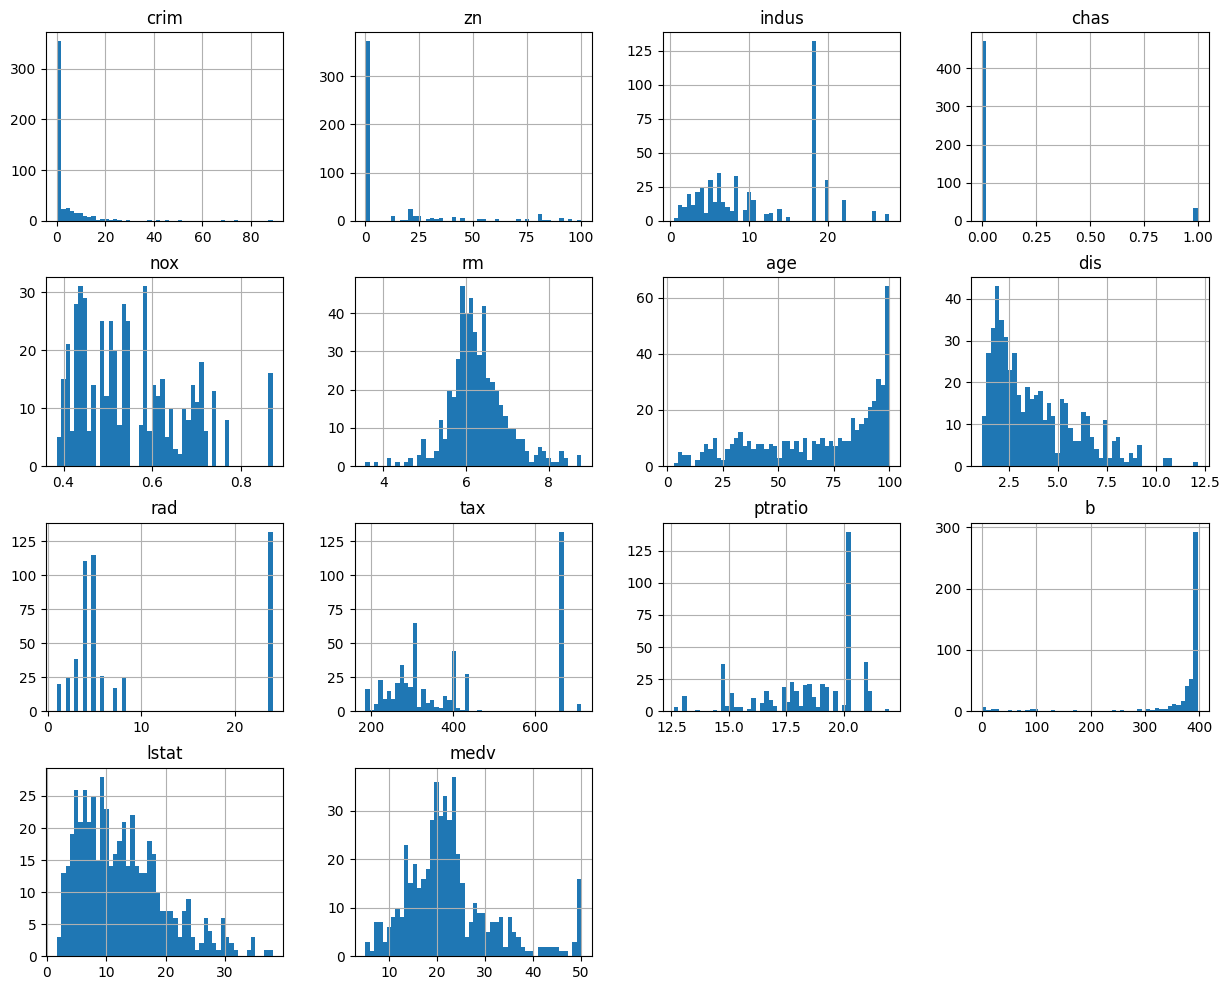

In [50]:
housing.hist(bins=50,figsize=(15,12))
plt.show()

## from the representaion of the diargram we can see that zn chas b and chrim have outliers

## Dealing with outliers

first lets express the outliers in terms of percentanges

In [51]:
for k , v in housing.items():
    q1=v.quantile(0.25)
    q2=v.quantile(0.75)
    iqr=q2-q1
    v_col = v[(v<=q1-1.5*iqr) | (v>=q2+1.5*iqr) ]
    perc = np.shape(v_col)[0] * 100 / np.shape(housing)[0]
    print(f"Columns {k}  outliers: {perc}%")


Columns crim  outliers: 13.043478260869565%
Columns zn  outliers: 13.438735177865613%
Columns indus  outliers: 0.0%
Columns chas  outliers: 100.0%
Columns nox  outliers: 0.0%
Columns rm  outliers: 5.928853754940712%
Columns age  outliers: 0.0%
Columns dis  outliers: 0.9881422924901185%
Columns rad  outliers: 0.0%
Columns tax  outliers: 0.0%
Columns ptratio  outliers: 2.964426877470356%
Columns b  outliers: 15.217391304347826%
Columns lstat  outliers: 1.383399209486166%
Columns medv  outliers: 7.905138339920948%


## Plotting the correlation matrix

<Axes: >

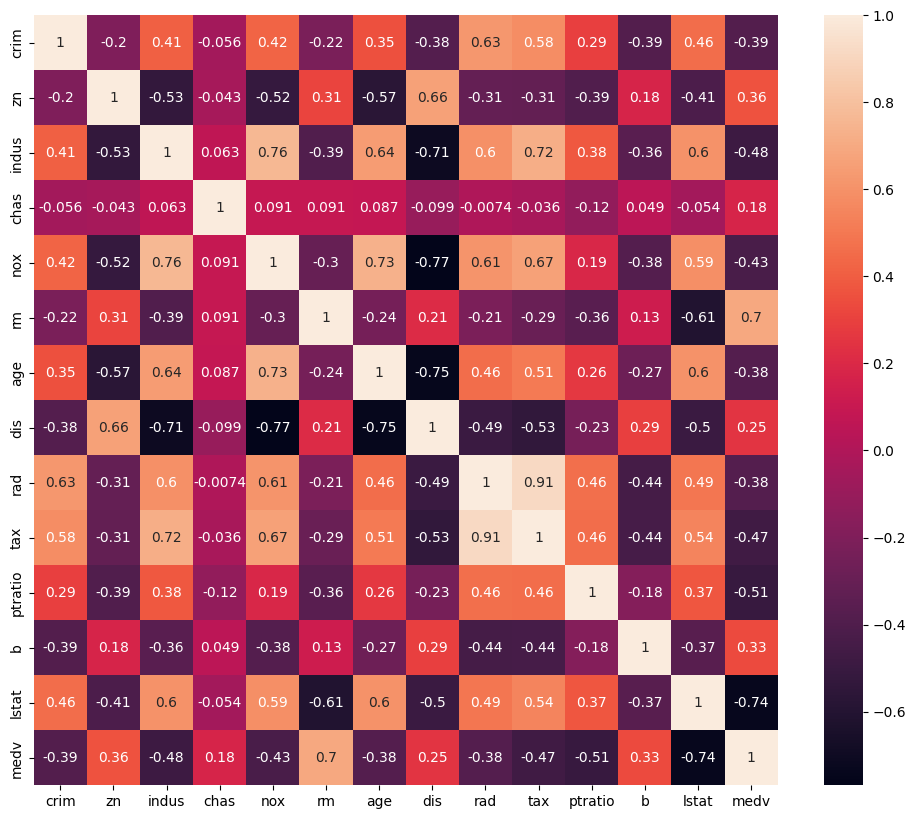

In [52]:
plt.figure(figsize=(12,10))
sns.heatmap(housing.corr(),annot=True)

In [53]:
## from the correlation map we can that the RM  and  lstat have very strong correlation against the medv which is our target
## Chas having the least correlation
## But overall most of the values have some good correlation towards the target

## Scaling our data
looking at our dataset we can see that the range of values is so different from the other values as in the ranges are quite big which may lead to bad perfomance

Machine Learning algorithms don’t perform well when the input numerical attributes have very different scales

In [54]:
scaler= StandardScaler()
#initializing the standard scaler

In [55]:
houscaled=scaler.fit_transform(housing)

In [ ]:
housecaled

In [56]:
houscaled.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

## Creating a test and a train set
for our case the target y will be the medv and the rest will be the feature X

In [ ]:
x=housing.drop('medv',axis=1)
y=housing["medv"]

x_scaled=scaler.fit_transform(x)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

## splitting the data with test data being 20% and the rest  80% is the training dataset

## Initializing the model and training the model under linear Regression 

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Making a prediction

In [ ]:
prediction=model.predict(x_test)

# Perfomance Measures

In [ ]:
scores=cross_val_score(model,x_test,y_test,cv=3,scoring="neg_mean_squared_error")
mse_scores=-scores
avg = np.sqrt(mse_scores.mean())

print(f"Root mean square Error:{avg}")

Root mean square Error:5.5154134702104285


In [ ]:
import joblib

In [ ]:
joblib.dump(model,"model2.pkl")

['model2.pkl']